#  Instruction Level Parallelism
# 1. Introduction
* CPU has multicore and SIMD parallelism
* The last dimension of parallelism is Instruction Level Parallelism (ILP), the ability to execute many instructions <font color=red>of a single thread</font> concurrently (i.e., execution of many instructions overlap in time)

# 2. Compilers
## 2-1. Set up NVIDIA HPC SDK
Execute this before you use NVIDIA HPC SDK

In [1]:
export PATH=/opt/nvidia/hpc_sdk/Linux_x86_64/22.11/compilers/bin:$PATH
#export PATH=/opt/nvidia/hpc_sdk/Linux_x86_64/22.9/compilers/bin:$PATH
#export PATH=/opt/nvidia/hpc_sdk/Linux_x86_64/22.7/compilers/bin:$PATH

Check if it works (check if full paths of nvc/nvc++ are shown)

In [2]:
which nvc
which nvc++

/opt/nvidia/hpc_sdk/Linux_x86_64/22.11/compilers/bin/nvc
/opt/nvidia/hpc_sdk/Linux_x86_64/22.11/compilers/bin/nvc++


## 2-2. Set up LLVM
Execute this before you use LLVM


In [3]:
export PATH=/home/share/llvm/bin:$PATH

Check if it works (check if full paths of gcc/g++ are shown)

In [4]:
which clang
which clang++

/home/share/llvm/bin/clang
/home/share/llvm/bin/clang++


## 2-3. GCC

Check if it works (check if full paths of nvc/nvc++ are shown)

In [5]:
which gcc
which g++

/usr/bin/gcc
/usr/bin/g++


# 3. No SIMD/ILP
* this is an experiment very similar to what we did on GPUs
* each thread repeats x = a * x + b many times and occasionally record time

In [6]:
%%writefile no_simd_no_ilp.c
// record of execution
typedef long long int llint;

enum { K = 1 };

typedef struct {
  double x[1];
  int vcore0; // a virtual core on which a thread got started
  int vcore1; // a virtual core on which a thread ended
} record_t;

#include "ilp_rec_main.h"

llint get_clock() {
  return _rdtsc();
}

/* this thread repeats x = a x + b (N * M) times.
   it records the clock N times (every M iterations of x = a x + b)
   to array T.
   final result of x = a x + b, as well as SM each thread was executed
   on are recorded to R. */
void thread_fun(double a, double b, record_t * R,
                llint * T, llint n, llint m) {
  int idx = omp_get_thread_num();
  // initial value (not important)
  double x = idx;
  
  // where clocks are recorded
  T = &T[idx * n];
  // record starting SM
  R[idx].vcore0 = sched_getcpu();
  // main thing. repeat a x + b many times,
  // occasionally recording the clock
  for (long i = 0; i < n; i++) {
    T[i] = get_clock();
    asm volatile("# begin loop");
    for (long j = 0; j < m; j++) {
      x = a * x + b;
    }
    asm volatile("# end loop");
  }
  // record ending SM (must be = sm0)
  R[idx].vcore1 = sched_getcpu();
  // record result, just so that the computation is not
  // eliminated by the compiler
  R[idx].x[0] = x;
}


Writing no_simd_no_ilp.c


In [7]:
clang -Wall -O3 -mavx512f -mfma -fopenmp no_simd_no_ilp.c -o no_simd_no_ilp
#nvc   -Wall -O3 -mavx512f -mfma -mp      no_simd_no_ilp.c -o no_simd_no_ilp
#gcc   -Wall -O3 -mavx512f -mfma -fopenmp no_simd_no_ilp.c -o no_simd_no_ilp

In [8]:
OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./no_simd_no_ilp 100 1000000

thread=0 vcore0=0 vcore1=0 x=100.000000 2850034153457188 2850034165544956 2850034169582084 2850034172439212 2850034175268106 2850034178105794 2850034180935024 2850034183758572 2850034186582120 2850034189426532 2850034192250080 2850034195083606 2850034197922252 2850034200745800 2850034203575516 2850034206399066 2850034209237906 2850034212066778 2850034214923708 2850034217767466 2850034220594234 2850034223417784 2850034226262452 2850034229086000 2850034231914926 2850034234738476 2850034237640292 2850034240556156 2850034243433600 2850034246279190 2850034249102738 2850034251926286 2850034254769460 2850034257593010 2850034260421710 2850034263245260 2850034266085024 2850034268914786 2850034271738334 2850034274580734 2850034277404282 2850034280227832 2850034283056270 2850034285893046 2850034288722864 2850034291549866 2850034294424214 2850034297253654 2850034300077202 2850034302922794 2850034305746344 2850034308569890 2850034311401150 2850034314241780 2850034317065328 2850034319893828 28500343

# 4. Visualizaiton
* here is a visualization code

In [9]:
#!/usr/bin/python3
import re
# from matplotlib import collections  as mc
import matplotlib.collections as mc
import matplotlib.pyplot as plt
import numpy as np

def read_dat(files_dat):
    pat = re.compile("thread=(?P<thread>\d+) vcore0=(?P<vcore0>\d+) vcore1=(?P<vcore1>\d+) x=(\d+\.\d+)(,\d+\.\d+)*(?P<t>( \d+)*)")
    log = {}
    for file_dat in files_dat:
        with open(file_dat) as fp:
            for line in fp:
                # 1 : 100.000000 20524414966449 20524423007875 0 0
                m = pat.match(line)
                if not m:
                    continue
                thread = int(m.group("thread"))
                # x      = float(m.group("x"))
                vcore0 = int(m.group("vcore0"))
                vcore1 = int(m.group("vcore1"))
                t      = [int(s) for s in m.group("t").strip().split()]
                # assert(vcore0 == vcore1), (vcore0, vcore1)
                if vcore0 not in log:
                    log[vcore0] = []
                log[vcore0].append((thread, t))
    return log

def ilp_plt(files_dat, start_t=0, end_t=float("inf"), start_thread=0, end_thread=float("inf")):
    log = read_dat(files_dat)
    n_vcores = max(vcore for vcore in log) + 1
    cmap = plt.cm.get_cmap('RdYlGn', n_vcores)
    fig, ax = plt.subplots()
    plt.xlabel("cycles")
    plt.ylabel("thread idx")
    T0 = min(min(T[0] for thread, T in records) for vcore,records in sorted(list(log.items())))
    for vcore,records in sorted(list(log.items())):
        X = []
        Y = []
        vcore_color = cmap(vcore)
        for thread, T in records:
            if start_thread <= thread < end_thread:
                for t in T:
                    if start_t <= t - T0 <= end_t:
                        X.append(t - T0)
                        Y.append(thread)
        ax.plot(X, Y, 'o', markersize=0.5, color=vcore_color)
    ax.autoscale()
    plt.savefig("sched.svg")
    plt.show()
    

# 5. Visualizaiton
* the following command line iterates `x = a * x + b` (100 x 10000) times and records the clock every 10000 iterations (i.e., the clock is recorded 100 times)

In [10]:
OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./no_simd_no_ilp 100 1000000 > no_simd_no_ilp.log

thread 0 : cycles/iter = 3.065045, fmas/cycle = 0.326259
fmas/cycle = 0.326259


* get the result in into a file and visualize it

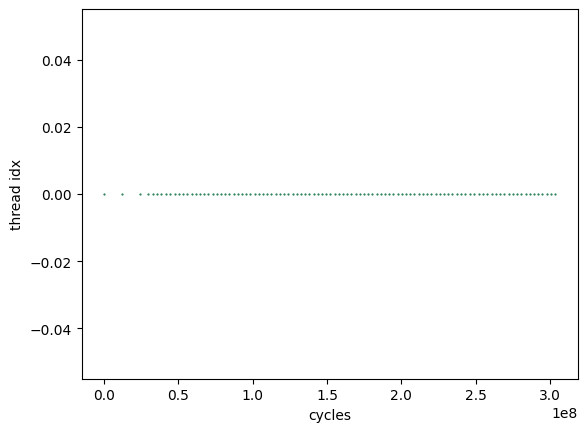

In [11]:
ilp_plt(["./no_simd_no_ilp.log"])

* how many cycles does a single `x = a * x + b` take?
* remember that this CPU's single-core peak performance is two SIMD DP FMA instructions/cycle (16 multiply-and-adds/cycle or 32 flops/cycle for double-precision numbers)
* the number you observed here should be far from it, just as it was the case in GPUs
* it is also equally true between CPUs and GPUs that you cannot run THIS computation any faster
* the performance of this computation is determined by the fact that
  * computing `a * x + b` takes a few cycles (has a certain LATENCY) and
  * performing `x = a * x + b` of an iteration <font color="red">must wait for the previous iteration to produce its result (`x`)</font>
* <font color="blue">the only thing processors can do to "increase performance" is to run MANY of them run in the same amount of time (i.e., increase parallelism)</font>
* the way we did it on <font color="blue">GPU was simply creating more and more threads</font>
* the way we do it on <font color="blue">CPU is to combine SIMD and ILP</font>


# 6. SIMD
* as you learned, you can run `x = a * x + b` for many (specifically eight DP or sixteeen SP) numbers using 512-bit SIMD instructions
* here is a simple SIMD version
* note: a computation as simple as below can be vectorized without using vector type, but we use it for the sake of clarity and guarantee

In [12]:
%%writefile simd_no_ilp.c
// record of execution
typedef long long int llint;
typedef double doublev __attribute__((vector_size(64), __may_alias__, aligned(sizeof(double))));
enum { L = sizeof(doublev) / sizeof(double) };

enum { K = L };

typedef struct {
  double x[K];                     // a (meaningless) answer
  int vcore0; // a virtual core on which a thread got started
  int vcore1; // a virtual core on which a thread ended
} record_t;

#include "ilp_rec_main.h"

llint get_clock() {
  return _rdtsc();
}

#define V(x) (*((doublev*)&x))
/* this thread repeats x = a x + b (N * M) times.
   it records the clock N times (every M iterations of x = a x + b)
   to array T.
   final result of x = a x + b, as well as SM each thread was executed
   on are recorded to R. */
void thread_fun(double a, double b, record_t * R,
                llint * T, llint n, llint m) {
  int idx = omp_get_thread_num();
  // initial value (not important)
  double x[K];
  for (long i = 0; i < K; i++) {
    x[i] = idx * K + i;
  }
  doublev x0 = V(x[0]);
  
  // where clocks are recorded
  T = &T[idx * n];
  // record starting SM
  R[idx].vcore0 = sched_getcpu();
  // main thing. repeat a x + b many times,
  // occasionally recording the clock
  for (long i = 0; i < n; i++) {
    T[i] = get_clock();
    asm volatile("# begin loop");
    for (long j = 0; j < m; j++) {
      x0 = a * x0 + b;
    }
    asm volatile("# end loop");
  }
  // record ending SM (must be = sm0)
  R[idx].vcore1 = sched_getcpu();
  // record result, just so that the computation is not
  // eliminated by the compiler
  V(x[0]) = x0;
  for (int i = 0; i < K; i++) {
    R[idx].x[i] = x[i];
  }
}


Writing simd_no_ilp.c


In [13]:

clang -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -o simd_no_ilp
#nvc   -Wall -O3 -mavx512f -mfma -mp      simd_no_ilp.c -o simd_no_ilp
#gcc   -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -o simd_no_ilp

In [14]:

OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./simd_no_ilp 100 1000000 > simd_no_ilp.log

thread 0 : cycles/iter = 4.250900, fmas/cycle = 1.881954
fmas/cycle = 1.881954


* the following should execute in almost the same time as the previous scalar version
* that is, SIMD fmadd instruction has the same latency as the scalar version

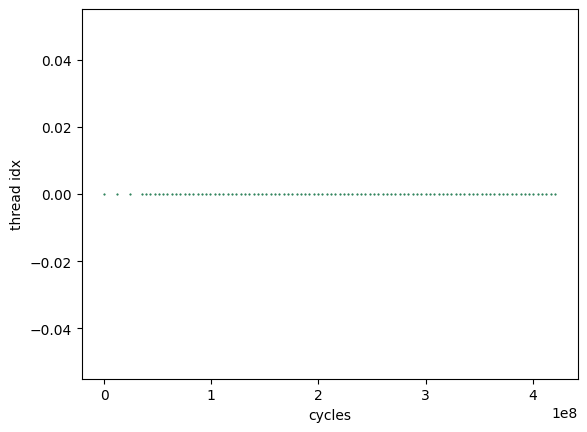

In [15]:
ilp_plt(["./simd_no_ilp.log"])

# 7. A note on two kinds of clocks
* you might observe that the gap between consecutive pair of points changes during the execution
* it happens because
  * recent CPUs boost frequencies of CPU cores (_core frequencies_) based on the load on cores (dynamic frequency scaling; aka "turbo boost" in Intel's terminology), and 
  * the clocks recorded by the program (obtained by `_rdtsc` function, which is `rdtsc` instruction of the CPU) are _reference clocks_ running at a constant frequency regardless of the CPU's core frequency
* in other words, the visualization shows how the iterations progress over _real time_
* when no or little computation is running, the processor's operating frequency tends to be low
* when a few cores are running intensively, the CPU boosts their frequencies
* when many cores are running, the CPU typically stays at the base clock to cap the power consumption

## 7-1. Measuring time in core cycles
* while our ultimate interest is the absolute time (or equivalently, reference clocks), it is often useful to measure the execution time in the number of core cycles, as it yields a more constant result no matter at which frequency the core happens to be running
* also, when you look up the processor spec that tells you the latency of a particular instruction in terms of clocks, it is the number of core cycles that the instruction takes
* for example, [Intel intrinsics guide](https://www.intel.com/content/www/us/en/docs/intrinsics-guide/index.html) guide says FMA instruction's latency is four cycles. it means it takes four core cycles, not reference cycles
* that's why you have observed that a single iteration took less than four cycles
* measuring the core clock is not as easy as measuring reference clock, but is possible thanks to Linux's perf API
* here is a version using perf API to obtain core cycles
* see the accompanying `perf.h` if you are interested

In [16]:
%%writefile simd_no_ilp.c
// record of execution
typedef long long int llint;
typedef double doublev __attribute__((vector_size(64), __may_alias__, aligned(sizeof(double))));
enum { L = sizeof(doublev) / sizeof(double) };

enum { K = L };

typedef struct {
  double x[K];                     // a (meaningless) answer
  int vcore0; // a virtual core on which a thread got started
  int vcore1; // a virtual core on which a thread ended
} record_t;

#include "ilp_rec_main.h"
#include "perf.h"

llint get_clock(perf_event_counter_t pc) {
#if CLOCK_IS_CORE_CLOCK
  /* get core clock */
  return perf_event_counter_get(pc);
#else
  /* read timestamp counter instruction (reference clock) */
  return _rdtsc();
#endif
}

#define V(x) (*((doublev*)&x))
/* this thread repeats x = a x + b (N * M) times.
   it records the clock N times (every M iterations of x = a x + b)
   to array T.
   final result of x = a x + b, as well as SM each thread was executed
   on are recorded to R. */
void thread_fun(double a, double b, record_t * R,
                llint * T, llint n, llint m) {
  int idx = omp_get_thread_num();
  // initial value (not important)
  double x[K];
  for (long i = 0; i < K; i++) {
    x[i] = idx * K + i;
  }
  doublev x0 = V(x[0]);
  
  // where clocks are recorded
  T = &T[idx * n];
  // record starting SM
  R[idx].vcore0 = sched_getcpu();
  // main thing. repeat a x + b many times,
  // occasionally recording the clock
  perf_event_counter_t pc = mk_perf_event_counter();
  for (long i = 0; i < n; i++) {
    T[i] = get_clock(pc);
    asm volatile("# begin loop");
    for (long j = 0; j < m; j++) {
      x0 = a * x0 + b;
    }
    asm volatile("# end loop");
  }
  perf_event_counter_destroy(pc);
  // record ending SM (must be = sm0)
  R[idx].vcore1 = sched_getcpu();
  // record result, just so that the computation is not
  // eliminated by the compiler
  V(x[0]) = x0;
  for (int i = 0; i < K; i++) {
    R[idx].x[i] = x[i];
  }
}


Overwriting simd_no_ilp.c


In [17]:

clang -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -o simd_no_ilp
#nvc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -mp      simd_no_ilp.c -o simd_no_ilp
#gcc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -o simd_no_ilp

* execute the following and get the number of core cycles per iteration
* it should be almost exactly four, the latency of an FMA instruction 
* you should check it at [Intel intrinsics guide](https://www.intel.com/content/www/us/en/docs/intrinsics-guide/index.html) (search for _mm512_fmadd_pd)

In [18]:

OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./simd_no_ilp 100 1000000 > simd_no_ilp.log

thread 0 : cycles/iter = 4.000989, fmas/cycle = 1.999505
fmas/cycle = 1.999505


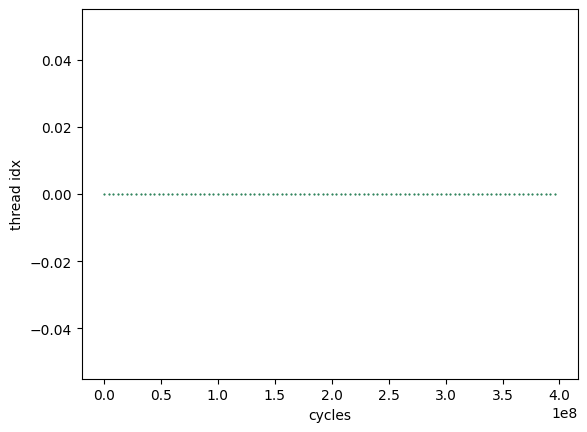

In [19]:
ilp_plt(["./simd_no_ilp.log"])

* also check the assembly code for what the loop actually looks like
* locate the code corresponding to the inner-most loop (`for (long j = 0; j < m; j++) ...`), using `# begin loop` and `# end loop` as landmarks

In [20]:

clang -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -S
#nvc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -mp      simd_no_ilp.c -S
#gcc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_no_ilp.c -S

# 8. SIMD x ILP
* with SIMD, it now performs a SIMD FMA (eight DP multiply-and-adds or sixteen DP flops) every four core cycles (0.25 FMA per cycle)
* still, it is still far from the peak, which is TWO FMAs every single cycle (1/8 of the peak)
* how to go beyond that?
* on a GPU SM, it was done just by increasing the number of CUDA threads thrown to a single SM
* on a CPU core, it is done by performing `x = a * x + b` on many different variables in a single thread

In [21]:
%%writefile simd_ilp2.c
// record of execution
typedef long long int llint;
typedef double doublev __attribute__((vector_size(64), __may_alias__, aligned(sizeof(double))));
enum { L = sizeof(doublev) / sizeof(double) };

enum { K = 2 * L };

typedef struct {
  double x[K];                     // a (meaningless) answer
  int vcore0; // a virtual core on which a thread got started
  int vcore1; // a virtual core on which a thread ended
} record_t;

#include "ilp_rec_main.h"
#include "perf.h"

llint get_clock(perf_event_counter_t pc) {
#if CLOCK_IS_CORE_CLOCK
  /* get core clock */
  return perf_event_counter_get(pc);
#else
  /* read timestamp counter instruction (reference clock) */
  return _rdtsc();
#endif
}

#define V(x) (*((doublev*)&x))
/* this thread repeats x = a x + b (N * M) times.
   it records the clock N times (every M iterations of x = a x + b)
   to array T.
   final result of x = a x + b, as well as SM each thread was executed
   on are recorded to R. */
void thread_fun(double a, double b, record_t * R,
                llint * T, llint n, llint m) {
  int idx = omp_get_thread_num();
  // initial value (not important)
  double x[K];
  for (long i = 0; i < K; i++) {
    x[i] = idx * K + i;
  }
  doublev x0 = V(x[0]);
  doublev x1 = V(x[L]);
  
  // where clocks are recorded
  T = &T[idx * n];
  // record starting SM
  R[idx].vcore0 = sched_getcpu();
  // main thing. repeat a x + b many times,
  // occasionally recording the clock
  perf_event_counter_t pc = mk_perf_event_counter();
  for (long i = 0; i < n; i++) {
    T[i] = get_clock(pc);
    asm volatile("# begin loop");
    for (long j = 0; j < m; j++) {
      x0 = a * x0 + b;
      x1 = a * x1 + b;
    }
    asm volatile("# end loop");
  }
  perf_event_counter_destroy(pc);
  // record ending SM (must be = sm0)
  R[idx].vcore1 = sched_getcpu();
  // record result, just so that the computation is not
  // eliminated by the compiler
  V(x[0]) = x0;
  V(x[L]) = x1;
  for (int i = 0; i < K; i++) {
    R[idx].x[i] = x[i];
  }
}


Writing simd_ilp2.c


In [22]:

clang -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp2.c -o simd_ilp2
#nvc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -mp      simd_ilp2.c -o simd_ilp2
#gcc   -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp2.c -o simd_ilp2

In [23]:

OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./simd_ilp2 100 1000000 > simd_ilp2.log

thread 0 : cycles/iter = 4.000801, fmas/cycle = 3.999199
fmas/cycle = 3.999199


* the following should execute in almost the same time as the previous scalar/SIMD version
* note that we doubled the amount of work, but the execution time stays almost the same, because these two instructions are independent and can run concurrently

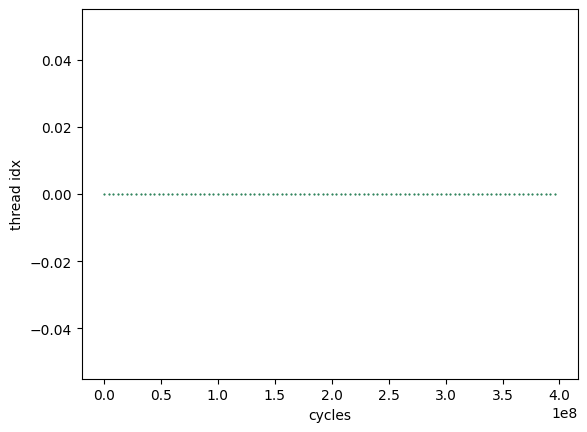

In [24]:
ilp_plt(["./simd_ilp2.log"])

In [25]:

clang -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp2.c -S
#nvc   -Wall -O3 -mavx512f -mfma -mp      simd_ilp2.c -S
#gcc   -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp2.c -S

# <font color="green"> Problem 1 :  Dependent or not: that is the problem</font>
* what happens if you change the two assignments
```
      x0 = a * x0 + b;
      x1 = a * x1 + b;
```
into 
```
      x0 = a * x1 + b;
      x1 = a * x0 + b;
```
?
* do it and see what happens
* explain why

YOUR ANSWER HERE
* the core cycles per iteration =

* the reason

# 9. Getting to a single-core peak
* we can have more than two variables and increase the number of concurrent operations, until we hopefully reach the peak
* doing it using literally many variables makes the program ugly
* the following program uses an array of doubles instead of multiple separate variables of `doublev`
* you can easily change the number of variables by setting a compile-time macro C at the command line by giving `-DC=x` (e.g., `-DC=2` will use two `doublev` variables (sixteen DP numbers))
* if the compiler is not clever, it may load and store values between memory and registers each time it performs fmadd
* fortunately, gcc and clang are clever enough to do the inner loop entirely on registers

In [26]:
%%writefile simd_ilp.c
// record of execution
typedef long long int llint;
typedef double doublev __attribute__((vector_size(64), __may_alias__, aligned(sizeof(double))));
enum { L = sizeof(doublev) / sizeof(double) };

#ifndef C
#define C 2
#endif
enum { K = C * L };

typedef struct {
  double x[K];                     // a (meaningless) answer
  int vcore0; // a virtual core on which a thread got started
  int vcore1; // a virtual core on which a thread ended
} record_t;

#include "ilp_rec_main.h"
#include "perf.h"

llint get_clock(perf_event_counter_t pc) {
#if CLOCK_IS_CORE_CLOCK
  /* get core clock */
  return perf_event_counter_get(pc);
#else
  /* read timestamp counter instruction (reference clock) */
  return _rdtsc();
#endif
}

#define V(x) (*((doublev*)&x))
/* this thread repeats x = a x + b (N * M) times.
   it records the clock N times (every M iterations of x = a x + b)
   to array T.
   final result of x = a x + b, as well as SM each thread was executed
   on are recorded to R. */
void thread_fun(double a, double b, record_t * R,
                llint * T, llint n, llint m) {
  int idx = omp_get_thread_num();
  // initial value (not important)
  double x[K];
  for (long i = 0; i < K; i++) {
    x[i] = idx * K + i;
  }
  
  // where clocks are recorded
  T = &T[idx * n];
  // record starting SM
  R[idx].vcore0 = sched_getcpu();
  // main thing. repeat a x + b many times,
  // occasionally recording the clock
  perf_event_counter_t pc = mk_perf_event_counter();
  for (long i = 0; i < n; i++) {
    T[i] = get_clock(pc);
    asm volatile("# begin loop");
    for (long j = 0; j < m; j++) {
      for (long k = 0; k < K; k += L) {
        V(x[k]) = a * V(x[k]) + b;
      }
    }
    asm volatile("# end loop");
  }
  perf_event_counter_destroy(pc);
  // record ending SM (must be = sm0)
  R[idx].vcore1 = sched_getcpu();
  // record result, just so that the computation is not
  // eliminated by the compiler
  for (int i = 0; i < K; i++) {
    R[idx].x[i] = x[i];
  }
}


Writing simd_ilp.c


# <font color="green"> Problem 2 :  Getting to a single-core peak</font>
* play with changing the value of `C` below and measure the execution time
* what is the minimum value of `C` that attains peak performance?
* what if you make `C` slightly larger?
* what if you make `C` even larger?

In [27]:

C=2
clang -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp
#nvc   -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -mp      simd_ilp.c -o simd_ilp
#gcc   -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp

In [28]:

OMP_NUM_THREADS=1 OMP_PROC_BIND=true ./simd_ilp 100 1000000 > simd_ilp.log

thread 0 : cycles/iter = 4.000986, fmas/cycle = 3.999015
fmas/cycle = 3.999015


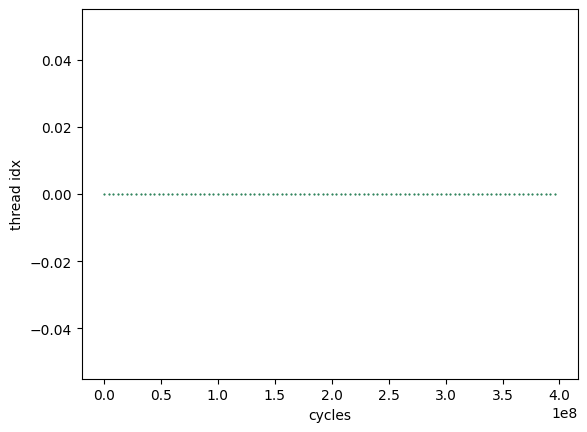

In [29]:
ilp_plt(["./simd_ilp.log"])

* run it with varying C's 

In [30]:

for C in $(seq 1 16); do 
    echo "=== C=${C} ==="
    clang -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp
    #nvc   -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -mp      simd_ilp.c -o simd_ilp
    #gcc   -DC=${C} -DCLOCK_IS_CORE_CLOCK=1 -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp
    OMP_NUM_THREADS=1 ./simd_ilp > ilp_rec.log
done

=== C=1 ===
thread 0 : cycles/iter = 4.001019, fmas/cycle = 1.999491
fmas/cycle = 1.999491
=== C=2 ===
thread 0 : cycles/iter = 4.000919, fmas/cycle = 3.999081
fmas/cycle = 3.999081
=== C=3 ===
thread 0 : cycles/iter = 4.001045, fmas/cycle = 5.998433
fmas/cycle = 5.998433
=== C=4 ===
thread 0 : cycles/iter = 4.000969, fmas/cycle = 7.998063
fmas/cycle = 7.998063
=== C=5 ===
thread 0 : cycles/iter = 4.025296, fmas/cycle = 9.937159
fmas/cycle = 9.937159
=== C=6 ===
thread 0 : cycles/iter = 4.115767, fmas/cycle = 11.662468
fmas/cycle = 11.662468
=== C=7 ===
thread 0 : cycles/iter = 4.330178, fmas/cycle = 12.932494
fmas/cycle = 12.932494
=== C=8 ===
thread 0 : cycles/iter = 4.348844, fmas/cycle = 14.716555
fmas/cycle = 14.716555
=== C=9 ===
thread 0 : cycles/iter = 4.696598, fmas/cycle = 15.330246
fmas/cycle = 15.330246
=== C=10 ===
thread 0 : cycles/iter = 5.043859, fmas/cycle = 15.860873
fmas/cycle = 15.860873
=== C=11 ===
thread 0 : cycles/iter = 5.515242, fmas/cycle = 15.955782
fmas/cyc

* copy the result below and draw the graph

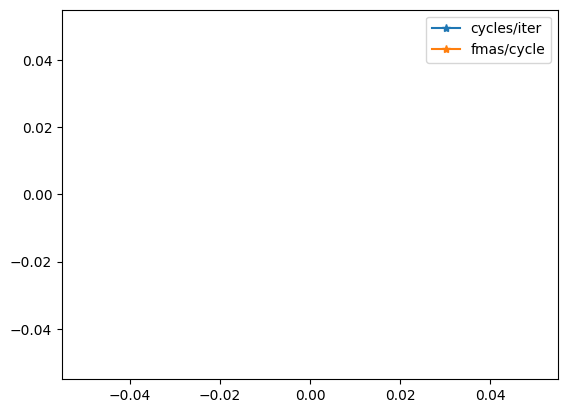

In [31]:
import re
import matplotlib.pyplot as plt

# copy the result below
result = """
=== C=1 ===
thread 0 : cycles/iter = ..., fmas/cycle = ...
fmas/cycle = ...
=== C=2 ===

   ...

=== C=12 ===
thread 0 : cycles/iter = ..., fmas/cycle = ...
fmas/cycle = ...
"""

def main():
    C = []
    cycles_per_iter = []
    fmas_per_cycle = []
    for line in result.strip().split("\n"):
        m = re.match("=== C=(?P<C>\d+) ===", line)
        if m:
            c = int(m.group("C"))
        m = re.match("thread (\d+) : cycles/iter = (?P<cpi>\d+\.\d+), fmas/cycle = (?P<fpc>\d+\.\d+)", line)
        if m:
            C.append(c)
            cycles_per_iter.append(float(m.group("cpi")))
            fmas_per_cycle.append(float(m.group("fpc")))
    cycles_per_iter_line, = plt.plot(C, cycles_per_iter, "-*")
    cycles_per_iter_line.set_label("cycles/iter")
    fmas_per_cycle_line, = plt.plot(C, fmas_per_cycle, "-*")
    fmas_per_cycle_line.set_label("fmas/cycle")
    plt.legend()
    plt.show()
    
main()            

# 10. SIMD x ILP x multicore
* finally run it with multicore to get nearly peak performance of the CPU!
* we use the reference clock to measure time, as core clocks are per-core clocks (it is misleading to put them in the same graph)

In [32]:

C=8
clang -DC=${C} -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp
#nvc   -DC=${C} -Wall -O3 -mavx512f -mfma -mp      simd_ilp.c -o simd_ilp
#gcc   -DC=${C} -Wall -O3 -mavx512f -mfma -fopenmp simd_ilp.c -o simd_ilp

In [33]:

OMP_NUM_THREADS=16 OMP_PROC_BIND=true ./simd_ilp 100 1000000 > simd_ilp_multicore.log

thread 0 : cycles/iter = 4.609940, fmas/cycle = 13.883043
thread 1 : cycles/iter = 4.413926, fmas/cycle = 14.499563
thread 2 : cycles/iter = 4.556627, fmas/cycle = 14.045478
thread 3 : cycles/iter = 4.400381, fmas/cycle = 14.544195
thread 4 : cycles/iter = 4.422404, fmas/cycle = 14.471768
thread 5 : cycles/iter = 4.419083, fmas/cycle = 14.482642
thread 6 : cycles/iter = 4.554486, fmas/cycle = 14.052080
thread 7 : cycles/iter = 4.411186, fmas/cycle = 14.508571
thread 8 : cycles/iter = 4.409219, fmas/cycle = 14.515041
thread 9 : cycles/iter = 4.405152, fmas/cycle = 14.528444
thread 10 : cycles/iter = 4.406399, fmas/cycle = 14.524332
thread 11 : cycles/iter = 4.552985, fmas/cycle = 14.056713
thread 12 : cycles/iter = 3.322581, fmas/cycle = 19.262131
thread 13 : cycles/iter = 4.409138, fmas/cycle = 14.515310
thread 14 : cycles/iter = 4.413997, fmas/cycle = 14.499331
thread 15 : cycles/iter = 4.562712, fmas/cycle = 14.026745
fmas/cycle = 222.128683


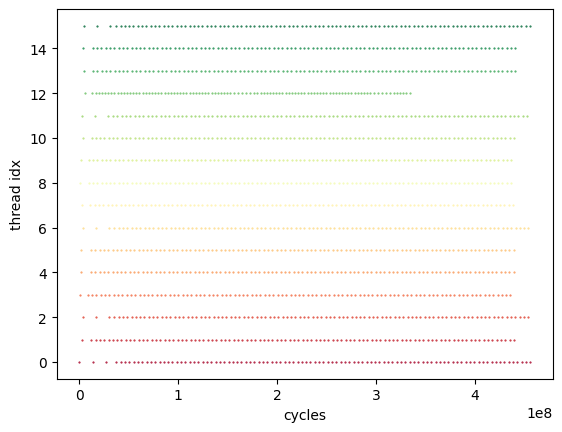

In [34]:
ilp_plt(["./simd_ilp_multicore.log"])

#  Remarks on multicore performance
* `OMP_PROC_BIND=true` above ensures each OpenMP thread is pinned to a virtual core (is not moved by the operating system) and to a distinct virtual core up to the number of virtual cores
* what we wish to observe is therefore that
  * the execution time does not increase up to the number of physical cores (38 in `taulec`) and
  * it increases up to 2x up to the number of virtual cores (76 in `taulec`)
* there are several reasons why it may not happen in practice
  1. two OpenMP threads of your program may happen to run on tho two virtual cores of the same physical core
  1. one of your OpenMP thread and another thread run by your friends may happen to run on the same virtual or physical core
  1. one of your OpenMP thread and other system services (Jupyter server, SSH server, etc.) may happen to run on the same virtual or physical core
* when you execute your program when many people are not using `taulec`, you are likely to be able to avoid the problems 2 and 3
* it is difficult to avoid the problem 1 in the virtualized environment (which taulec is), as the mapping between CPU number seen in taulec and the physical core is unknown and can even change at runtime
  * in physical machines, you can know which virtual cores visible in the environment share the same physical core, so, using appropriate Linux tools (e.g., taskset or numactl), you can guarantee that only one virtual core on each physical core is used to run your program 
* if two threads that would reach the peak performance happen to run on the two virtual cores of the same physical core, each thread gets half of the peak performance
* therefore what you can hope is that the execution time becomes 2x at the worst case, up to the number of virtual cores (76 in `taulec`)
* even this may not happen due to the problems 2 and 3, especially when many users use `taulec` (try at night)